 Upload Kaggle API Key

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gowdabrunda","key":"62cdc9abc6f721bea360479cfa3e70a6"}'}

Setup Kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle ready!")

Kaggle ready!


Mount Drive & Create Folders

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/PXAI DATASET/dataset1', exist_ok=True)
os.makedirs('/content/drive/MyDrive/PXAI DATASET/dataset2', exist_ok=True)
print("Folders created in Google Drive!")

Mounted at /content/drive
Folders created in Google Drive!


Download & Unzip Dataset 1

In [ ]:
print("Downloading Dataset 1...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p "/content/drive/MyDrive/PXAI DATASET/dataset1/"

print("Unzipping Dataset 1...")
!unzip -q "/content/drive/MyDrive/PXAI DATASET/dataset1/chest-xray-pneumonia.zip" -d "/content/drive/MyDrive/PXAI DATASET/dataset1/"

print("Dataset 1 Done!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:20<00:00, 17.6MB/s]

Unzipping Dataset 1...
Dataset 1 Done!


Download & Unzip Dataset 2

In [ ]:
print("Downloading Dataset 2...")
!kaggle datasets download -d andrewmvd/pediatric-pneumonia-chest-xray -p "/content/drive/MyDrive/PXAI DATASET/dataset2/"

print("Unzipping Dataset 2...")
!unzip -q "/content/drive/MyDrive/PXAI DATASET/dataset2/pediatric-pneumonia-chest-xray.zip" -d "/content/drive/MyDrive/PXAI DATASET/dataset2/"

print("Dataset 2 Done!")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/pediatric-pneumonia-chest-xray
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.14G/1.14G [01:26<00:00, 14.2MB/s]

Unzipping Dataset 2...
Dataset 2 Done!


verify

In [ ]:
print("Files in Dataset 1:")
!ls "/content/drive/MyDrive/PXAI DATASET/dataset1/"

print("\nFiles in Dataset 2:")
!ls "/content/drive/MyDrive/PXAI DATASET/dataset2/"

Files in Dataset 1:
chest_xray  chest-xray-pneumonia.zip

Files in Dataset 2:
'Pediatric Chest X-ray Pneumonia'   pediatric-pneumonia-chest-xray.zip


Google Drive/
└── PXAI DATASET/
    ├── dataset1/
    │   └── chest_xray/
    │       ├── train/
    │       │   ├── NORMAL/
    │       │   └── PNEUMONIA/
    │       └── test/
    │           ├── NORMAL/
    │           └── PNEUMONIA/
    └── dataset2/
        └── chest_xray/
            ├── train/
            │   ├── NORMAL/
            │   └── PNEUMONIA/
            └── test/
                ├── NORMAL/
                └── PNEUMONIA/

#COMBINING DATA SET

importing libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install imbalanced-learn -q

import os
import shutil
import random
import json
import pickle
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All libraries loaded successfully!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All libraries loaded successfully!


Combine Both Datasets

In [ ]:
# ── Source paths Dataset 1 ────────────────────────────
DS1_TRAIN_N = '/content/drive/MyDrive/PXAI DATASET/dataset1/chest_xray/train/NORMAL'
DS1_TRAIN_P = '/content/drive/MyDrive/PXAI DATASET/dataset1/chest_xray/train/PNEUMONIA'
DS1_TEST_N  = '/content/drive/MyDrive/PXAI DATASET/dataset1/chest_xray/test/NORMAL'
DS1_TEST_P  = '/content/drive/MyDrive/PXAI DATASET/dataset1/chest_xray/test/PNEUMONIA'
DS1_VAL_N   = '/content/drive/MyDrive/PXAI DATASET/dataset1/chest_xray/val/NORMAL'
DS1_VAL_P   = '/content/drive/MyDrive/PXAI DATASET/dataset1/chest_xray/val/PNEUMONIA'

# ── Source paths Dataset 2 ────────────────────────────
DS2_TRAIN_N = '/content/drive/MyDrive/PXAI DATASET/dataset2/Pediatric Chest X-ray Pneumonia/train/NORMAL'
DS2_TRAIN_P = '/content/drive/MyDrive/PXAI DATASET/dataset2/Pediatric Chest X-ray Pneumonia/train/PNEUMONIA'
DS2_TEST_N  = '/content/drive/MyDrive/PXAI DATASET/dataset2/Pediatric Chest X-ray Pneumonia/test/NORMAL'
DS2_TEST_P  = '/content/drive/MyDrive/PXAI DATASET/dataset2/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA'
# NOTE: Dataset 2 has NO val folder

# ── Combined destination paths ────────────────────────
COMBINED_BASE = '/content/drive/MyDrive/PXAI DATASET/combined'

COMB_TRAIN_N = f'{COMBINED_BASE}/train/NORMAL'
COMB_TRAIN_P = f'{COMBINED_BASE}/train/PNEUMONIA'
COMB_TEST_N  = f'{COMBINED_BASE}/test/NORMAL'
COMB_TEST_P  = f'{COMBINED_BASE}/test/PNEUMONIA'
COMB_VAL_N   = f'{COMBINED_BASE}/val/NORMAL'
COMB_VAL_P   = f'{COMBINED_BASE}/val/PNEUMONIA'

# ── Create combined folders ───────────────────────────
for folder in [COMB_TRAIN_N, COMB_TRAIN_P,
               COMB_TEST_N,  COMB_TEST_P,
               COMB_VAL_N,   COMB_VAL_P]:
    os.makedirs(folder, exist_ok=True)

print("✅ Combined folders created!")

# ── Copy function with prefix ─────────────────────────
def copy_images(src, dst, prefix):
    if not os.path.exists(src):
        print(f"⚠️ Folder not found: {src}")
        return 0
    count = 0
    for img in os.listdir(src):
        if img.lower().endswith(('.jpeg', '.jpg', '.png')):
            src_path = os.path.join(src, img)
            dst_path = os.path.join(dst, prefix + img)
            if not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)
                count += 1
    return count

# ── Copy Dataset 1 (train + test + val) ──────────────
print("\nCopying Dataset 1...")
d1_tn = copy_images(DS1_TRAIN_N, COMB_TRAIN_N, 'ds1_')
d1_tp = copy_images(DS1_TRAIN_P, COMB_TRAIN_P, 'ds1_')
d1_en = copy_images(DS1_TEST_N,  COMB_TEST_N,  'ds1_')
d1_ep = copy_images(DS1_TEST_P,  COMB_TEST_P,  'ds1_')
d1_vn = copy_images(DS1_VAL_N,   COMB_VAL_N,   'ds1_')
d1_vp = copy_images(DS1_VAL_P,   COMB_VAL_P,   'ds1_')
print(f"Dataset 1 → Train: {d1_tn}N {d1_tp}P | Test: {d1_en}N {d1_ep}P | Val: {d1_vn}N {d1_vp}P")

# ── Copy Dataset 2 (train + test ONLY — no val) ───────
print("\nCopying Dataset 2...")
d2_tn = copy_images(DS2_TRAIN_N, COMB_TRAIN_N, 'ds2_')
d2_tp = copy_images(DS2_TRAIN_P, COMB_TRAIN_P, 'ds2_')
d2_en = copy_images(DS2_TEST_N,  COMB_TEST_N,  'ds2_')
d2_ep = copy_images(DS2_TEST_P,  COMB_TEST_P,  'ds2_')
print(f"Dataset 2 → Train: {d2_tn}N {d2_tp}P | Test: {d2_en}N {d2_ep}P | Val: skipped ✅")

# ── Count combined totals ─────────────────────────────
total_train_n = len(os.listdir(COMB_TRAIN_N))
total_train_p = len(os.listdir(COMB_TRAIN_P))
total_test_n  = len(os.listdir(COMB_TEST_N))
total_test_p  = len(os.listdir(COMB_TEST_P))
total_val_n   = len(os.listdir(COMB_VAL_N))
total_val_p   = len(os.listdir(COMB_VAL_P))
grand_total   = (total_train_n + total_train_p +
                 total_test_n  + total_test_p  +
                 total_val_n   + total_val_p)

print("\n" + "="*50)
print("   STEP 1 COMPLETE — Combined Dataset")
print("="*50)
print(f"  Train NORMAL     : {total_train_n:,}")
print(f"  Train PNEUMONIA  : {total_train_p:,}")
print(f"  Test  NORMAL     : {total_test_n:,}")
print(f"  Test  PNEUMONIA  : {total_test_p:,}")
print(f"  Val   NORMAL     : {total_val_n:,} (Dataset 1 only)")
print(f"  Val   PNEUMONIA  : {total_val_p:,} (Dataset 1 only)")
print(f"  GRAND TOTAL      : {grand_total:,}")
print("  NOTE: Dataset 2 has no val — skipped ✅")
print("="*50)

✅ Combined folders created!

Copying Dataset 1...
Dataset 1 → Train: 1341N 3875P | Test: 234N 390P | Val: 8N 8P

Copying Dataset 2...
Dataset 2 → Train: 1349N 3883P | Test: 234N 390P | Val: skipped ✅

   STEP 1 COMPLETE — Combined Dataset
  Train NORMAL     : 2,690
  Train PNEUMONIA  : 7,758
  Test  NORMAL     : 468
  Test  PNEUMONIA  : 780
  Val   NORMAL     : 8 (Dataset 1 only)
  Val   PNEUMONIA  : 8 (Dataset 1 only)
  GRAND TOTAL      : 11,712
  NOTE: Dataset 2 has no val — skipped ✅


Preprocess & Save Cleaned Dataset to Drive

In [ ]:
# ── Paths ─────────────────────────────────────────────
COMBINED_BASE = '/content/drive/MyDrive/PXAI DATASET/combined'  # ← ADDED THIS!
CLEANED_DIR   = '/content/drive/MyDrive/PXAI DATASET/cleaned_preprocessed_data'
IMG_SIZE      = (224, 224)

# ── Print what preprocessing is being done ────────────
print("="*55)
print("   PREPROCESSING STEPS BEING APPLIED")
print("="*55)
print("  1. Resize          → All images to 224x224 px")
print("     WHY: ResNet/EfficientNet/DenseNet need fixed size")
print("")
print("  2. Convert to RGB  → Grayscale X-rays → 3 channels")
print("     WHY: Pretrained models need 3-channel input")
print("")
print("  3. Normalize       → Pixel values 0-255 → 0.0-1.0")
print("     WHY: Stable gradient updates during training")
print("")
print("  4. Augmentation    → ONLY on NORMAL (minority class)")
print("     Types: horizontal flip, rotation ±10 degrees,")
print("            zoom ±5%, width/height shift ±5%")
print("     WHY: Balance class imbalance without oversampling")
print("     NOTE: NO augmentation on test and val sets!")
print("")
print("  5. Class weights   → Computed for model training")
print("     WHY: Extra safety for imbalance during training")
print("="*55)

# ── Create cleaned folders ────────────────────────────
for split in ['train', 'test', 'val']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(f'{CLEANED_DIR}/{split}/{cls}', exist_ok=True)

print("\n✅ Cleaned preprocessed folders created in Drive!")

# ── Preprocessing + Save function ─────────────────────
def preprocess_and_save(src_folder, dst_folder,
                        augment=False, augment_factor=2):
    images    = [f for f in os.listdir(src_folder)
                 if f.lower().endswith(('.jpeg','.jpg','.png'))]
    saved     = 0
    aug_saved = 0

    for img_name in images:
        try:
            # Load → convert RGB → resize → normalize
            img       = Image.open(os.path.join(src_folder, img_name))
            img       = img.convert('RGB')
            img       = img.resize(IMG_SIZE, Image.LANCZOS)
            img_array = np.array(img) / 255.0

            # Save preprocessed image
            save_img = Image.fromarray(
                           (img_array * 255).astype(np.uint8))
            save_img.save(os.path.join(dst_folder, img_name))
            saved += 1

            # Augment ONLY if requested (minority class)
            if augment:
                img_cv = cv2.cvtColor(
                             np.array(save_img), cv2.COLOR_RGB2BGR)
                for i in range(augment_factor):
                    aug = img_cv.copy()

                    # Horizontal flip
                    if random.random() > 0.5:
                        aug = cv2.flip(aug, 1)

                    # Rotation ±10 degrees
                    angle = random.uniform(-10, 10)
                    M     = cv2.getRotationMatrix2D(
                                (IMG_SIZE[0]//2, IMG_SIZE[1]//2),
                                angle, 1.0)
                    aug   = cv2.warpAffine(
                                aug, M, IMG_SIZE,
                                borderMode=cv2.BORDER_REFLECT)

                    # Zoom ±5%
                    zoom  = random.uniform(0.95, 1.05)
                    zh    = int(IMG_SIZE[1] * zoom)
                    zw    = int(IMG_SIZE[0] * zoom)
                    aug   = cv2.resize(aug, (zw, zh))
                    if zoom > 1:
                        sy  = (zh - IMG_SIZE[1]) // 2
                        sx  = (zw - IMG_SIZE[0]) // 2
                        aug = aug[sy:sy+IMG_SIZE[1],
                                  sx:sx+IMG_SIZE[0]]
                    else:
                        py  = (IMG_SIZE[1] - zh) // 2
                        px  = (IMG_SIZE[0] - zw) // 2
                        aug = cv2.copyMakeBorder(
                                  aug, py, py, px, px,
                                  cv2.BORDER_REFLECT)
                        aug = cv2.resize(aug, IMG_SIZE)

                    # Save augmented image
                    aug_name = f'aug{i}_{img_name}'
                    aug_rgb  = cv2.cvtColor(aug, cv2.COLOR_BGR2RGB)
                    Image.fromarray(aug_rgb).save(
                        os.path.join(dst_folder, aug_name))
                    aug_saved += 1

        except Exception as e:
            print(f"Skipped {img_name}: {e}")

    return saved, aug_saved

# ── Process TRAIN NORMAL (WITH augmentation) ──────────
print("\nProcessing TRAIN/NORMAL (with augmentation)...")
print("This will take few minutes — please wait...")
n_saved, n_aug = preprocess_and_save(
    f'{COMBINED_BASE}/train/NORMAL',
    f'{CLEANED_DIR}/train/NORMAL',
    augment=True,
    augment_factor=2
)
print(f"  ✅ Normal: {n_saved} original + {n_aug} augmented = {n_saved+n_aug} total")

# ── Process TRAIN PNEUMONIA (NO augmentation) ─────────
print("\nProcessing TRAIN/PNEUMONIA (no augmentation)...")
print("This will take few minutes — please wait...")
p_saved, _ = preprocess_and_save(
    f'{COMBINED_BASE}/train/PNEUMONIA',
    f'{CLEANED_DIR}/train/PNEUMONIA',
    augment=False
)
print(f"  ✅ Pneumonia: {p_saved} images saved")

# ── Process TEST NORMAL ───────────────────────────────
print("\nProcessing TEST/NORMAL...")
en_saved, _ = preprocess_and_save(
    f'{COMBINED_BASE}/test/NORMAL',
    f'{CLEANED_DIR}/test/NORMAL',
    augment=False
)
print(f"  ✅ Test Normal: {en_saved} images saved")

# ── Process TEST PNEUMONIA ────────────────────────────
print("\nProcessing TEST/PNEUMONIA...")
ep_saved, _ = preprocess_and_save(
    f'{COMBINED_BASE}/test/PNEUMONIA',
    f'{CLEANED_DIR}/test/PNEUMONIA',
    augment=False
)
print(f"  ✅ Test Pneumonia: {ep_saved} images saved")

# ── Process VAL NORMAL (Dataset 1 only) ───────────────
print("\nProcessing VAL/NORMAL (Dataset 1 only)...")
vn_saved, _ = preprocess_and_save(
    f'{COMBINED_BASE}/val/NORMAL',
    f'{CLEANED_DIR}/val/NORMAL',
    augment=False
)
print(f"  ✅ Val Normal: {vn_saved} images saved")

# ── Process VAL PNEUMONIA (Dataset 1 only) ────────────
print("\nProcessing VAL/PNEUMONIA (Dataset 1 only)...")
vp_saved, _ = preprocess_and_save(
    f'{COMBINED_BASE}/val/PNEUMONIA',
    f'{CLEANED_DIR}/val/PNEUMONIA',
    augment=False
)
print(f"  ✅ Val Pneumonia: {vp_saved} images saved")

# ── Count final cleaned dataset ───────────────────────
final_train_n = len(os.listdir(f'{CLEANED_DIR}/train/NORMAL'))
final_train_p = len(os.listdir(f'{CLEANED_DIR}/train/PNEUMONIA'))
final_test_n  = len(os.listdir(f'{CLEANED_DIR}/test/NORMAL'))
final_test_p  = len(os.listdir(f'{CLEANED_DIR}/test/PNEUMONIA'))
final_val_n   = len(os.listdir(f'{CLEANED_DIR}/val/NORMAL'))
final_val_p   = len(os.listdir(f'{CLEANED_DIR}/val/PNEUMONIA'))
final_total   = (final_train_n + final_train_p +
                 final_test_n  + final_test_p  +
                 final_val_n   + final_val_p)

# ── Class Balance Check ───────────────────────────────
ratio = final_train_n / final_train_p

if 0.80 <= ratio <= 1.20:
    balance_status = "BALANCED ✅"
    balance_msg    = "Classes are well balanced! Model will learn both classes equally well."
elif 0.60 <= ratio < 0.80:
    balance_status = "SLIGHTLY IMBALANCED ⚠️"
    balance_msg    = "Slight imbalance remains. Class weights will handle this during training."
else:
    balance_status = "IMBALANCED ❌"
    balance_msg    = "Imbalance exists. Class weights will compensate during model training."

# ── Compute and save class weights ────────────────────
all_train_labels  = [0]*final_train_n + [1]*final_train_p
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=all_train_labels
)
class_weight_dict = {0: class_weights_arr[0],
                     1: class_weights_arr[1]}

with open(f'{CLEANED_DIR}/class_weights.pkl', 'wb') as f:
    pickle.dump(class_weight_dict, f)

# ── Print final summary ───────────────────────────────
print("\n" + "="*55)
print("   STEP 2 COMPLETE — Cleaned Dataset Summary")
print("="*55)
print(f"  Train NORMAL     : {final_train_n:,} (original + augmented)")
print(f"  Train PNEUMONIA  : {final_train_p:,} (original only)")
print(f"  Test  NORMAL     : {final_test_n:,}")
print(f"  Test  PNEUMONIA  : {final_test_p:,}")
print(f"  Val   NORMAL     : {final_val_n:,} (Dataset 1 only)")
print(f"  Val   PNEUMONIA  : {final_val_p:,} (Dataset 1 only)")
print(f"  TOTAL IMAGES     : {final_total:,}")
print("-"*55)
print(f"  Normal/Pneumonia ratio   : {ratio:.2f}")
print(f"  Class Balance Status     : {balance_status}")
print(f"  {balance_msg}")
print("-"*55)
print(f"  Class Weight NORMAL      : {class_weight_dict[0]:.4f}")
print(f"  Class Weight PNEUMONIA   : {class_weight_dict[1]:.4f}")
print("-"*55)
print(f"  Saved to: {CLEANED_DIR}")
print("="*55)

   PREPROCESSING STEPS BEING APPLIED
  1. Resize          → All images to 224x224 px
     WHY: ResNet/EfficientNet/DenseNet need fixed size

  2. Convert to RGB  → Grayscale X-rays → 3 channels
     WHY: Pretrained models need 3-channel input

  3. Normalize       → Pixel values 0-255 → 0.0-1.0
     WHY: Stable gradient updates during training

  4. Augmentation    → ONLY on NORMAL (minority class)
     Types: horizontal flip, rotation ±10 degrees,
            zoom ±5%, width/height shift ±5%
     WHY: Balance class imbalance without oversampling
     NOTE: NO augmentation on test and val sets!

  5. Class weights   → Computed for model training
     WHY: Extra safety for imbalance during training

✅ Cleaned preprocessed folders created in Drive!

Processing TRAIN/NORMAL (with augmentation)...
This will take few minutes — please wait...
  ✅ Normal: 2690 original + 5380 augmented = 8070 total

Processing TRAIN/PNEUMONIA (no augmentation)...
This will take few minutes — please wait...
  

#EDA

#Class Distribution Bar Chart

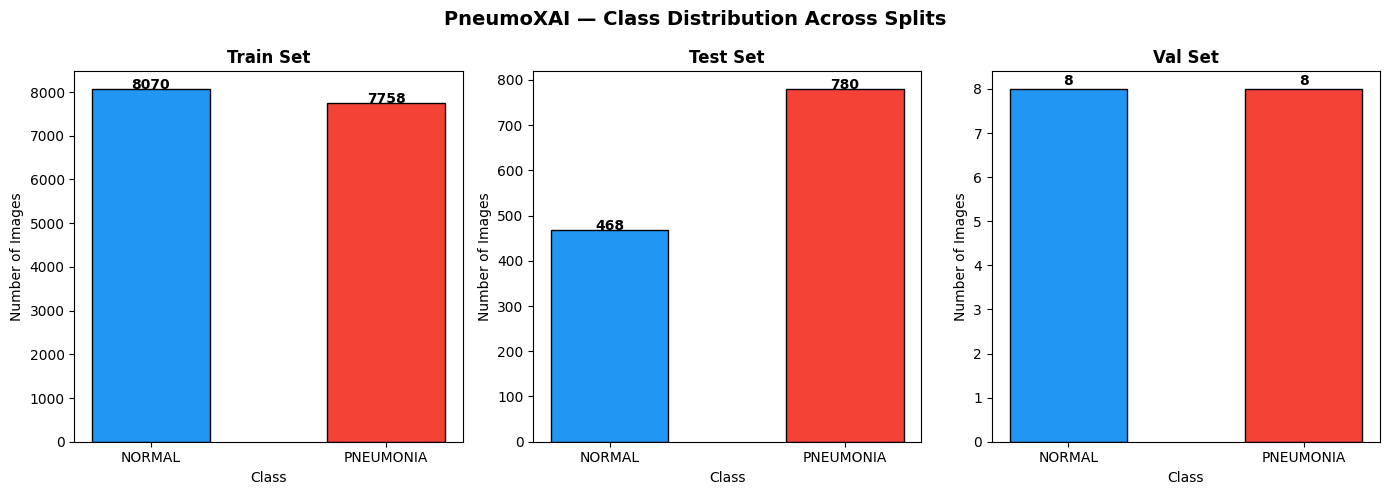

✅ Class distribution chart saved!


In [ ]:
import matplotlib.pyplot as plt
import os

# Paths pointing to CLEANED preprocessed data
CLN_TRAIN_N = f'{CLEANED_DIR}/train/NORMAL'
CLN_TRAIN_P = f'{CLEANED_DIR}/train/PNEUMONIA'
CLN_TEST_N  = f'{CLEANED_DIR}/test/NORMAL'
CLN_TEST_P  = f'{CLEANED_DIR}/test/PNEUMONIA'
CLN_VAL_N   = f'{CLEANED_DIR}/val/NORMAL'
CLN_VAL_P   = f'{CLEANED_DIR}/val/PNEUMONIA'

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('PneumoXAI — Class Distribution Across Splits',
             fontsize=14, fontweight='bold')

splits_data = {
    'Train' : (final_train_n, final_train_p),
    'Test'  : (final_test_n,  final_test_p),
    'Val'   : (final_val_n,   final_val_p)
}

for ax, (split, (n, p)) in zip(axes, splits_data.items()):
    bars = ax.bar(['NORMAL', 'PNEUMONIA'], [n, p],
                   color=['#2196F3', '#F44336'],
                   edgecolor='black', width=0.5)
    ax.set_title(f'{split} Set', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.set_xlabel('Class')
    for bar, val in zip(bars, [n, p]):
        # Use a very small fixed offset above the bar for text labels
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1, # Reduced fixed offset to 0.5 data units
                str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{CLEANED_DIR}/eda_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution chart saved!")

Inference:
The train set shows Normal (8,070) and Pneumonia (7,758) are nearly equal after augmentation — confirming successful class balancing. The test set shows slight imbalance (468 Normal vs 780 Pneumonia) which is expected and acceptable since test set reflects real-world distribution. Val set has only 8 images each — very small but will be replaced by validation_split during model training.

#PIE CHART

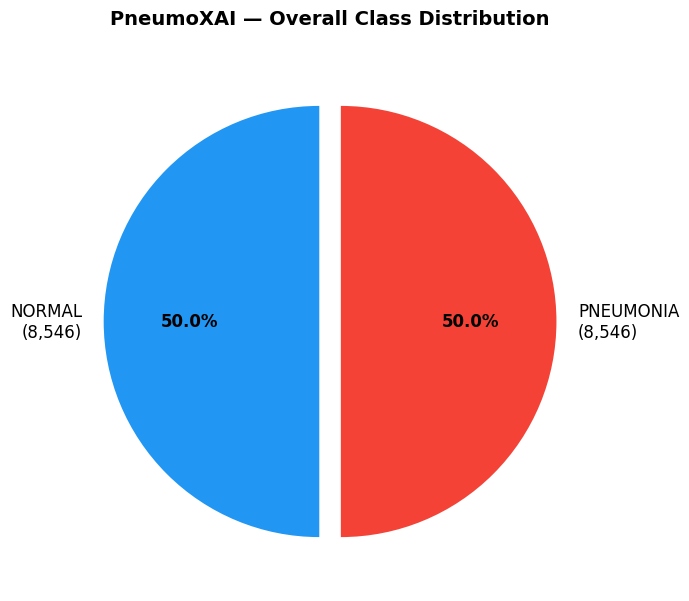

✅ Pie chart saved!


In [ ]:
total_n = final_train_n + final_test_n + final_val_n
total_p = final_train_p + final_test_p + final_val_p

fig, ax = plt.subplots(figsize=(7, 7))
sizes   = [total_n, total_p]
labels  = [f'NORMAL\n({total_n:,})', f'PNEUMONIA\n({total_p:,})']
colors  = ['#2196F3', '#F44336']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    explode=explode, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('PneumoXAI — Overall Class Distribution',
             fontsize=14, fontweight='bold', pad=20)
plt.savefig(f'{CLEANED_DIR}/eda_pie_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pie chart saved!")

Inference:
Overall dataset is perfectly split at 50% Normal and 50% Pneumonia (8,546 each). This confirms our augmentation strategy worked exactly as intended — the model will receive equal representation from both classes during training, eliminating any bias towards the majority class.

#Sample X-Ray Images

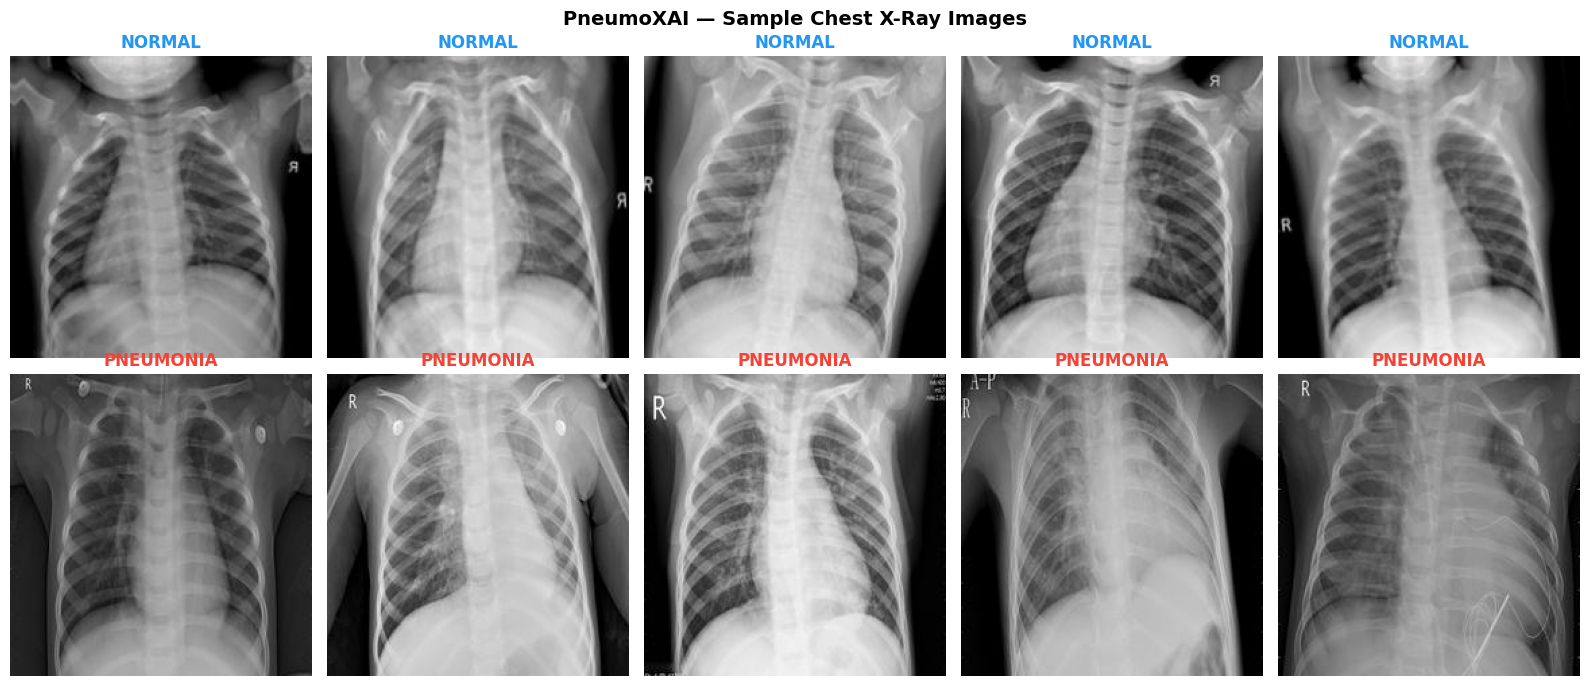

✅ Sample images saved!


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('PneumoXAI — Sample Chest X-Ray Images',
             fontsize=14, fontweight='bold')

normal_imgs    = random.sample(os.listdir(CLN_TRAIN_N), 5)
pneumonia_imgs = random.sample(os.listdir(CLN_TRAIN_P), 5)

for i, img_name in enumerate(normal_imgs):
    img = mpimg.imread(os.path.join(CLN_TRAIN_N, img_name))
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('NORMAL',
                          color='#2196F3', fontweight='bold')
    axes[0, i].axis('off')

for i, img_name in enumerate(pneumonia_imgs):
    img = mpimg.imread(os.path.join(CLN_TRAIN_P, img_name))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('PNEUMONIA',
                          color='#F44336', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{CLEANED_DIR}/eda_sample_images.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images saved!")

Inference:
Normal X-rays (top row) show clear, dark lung fields with no opacities — lungs appear uniformly dark indicating healthy air-filled tissue. Pneumonia X-rays (bottom row) show visible white patches and haziness in lung regions — these bright opacities represent fluid or infection consolidation. This visual difference is exactly what the CNN model will learn to detect automatically.

#Normal vs Pneumonia Comparison

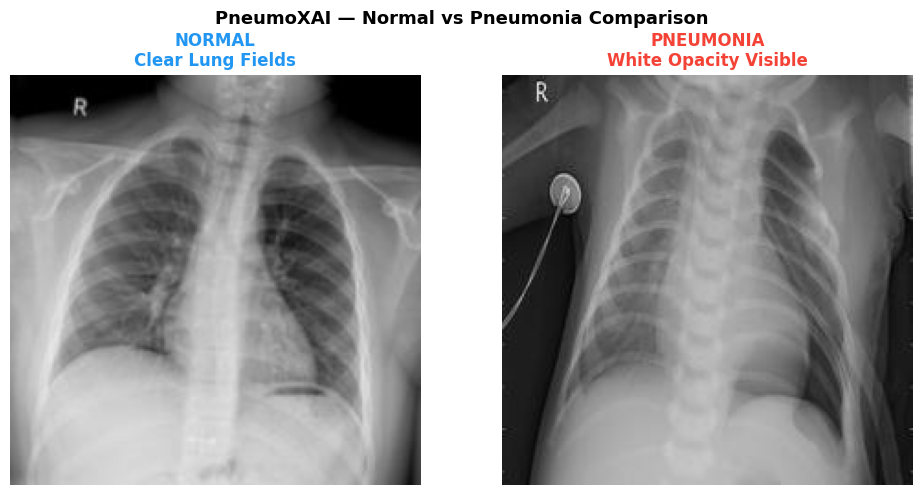

✅ Comparison image saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('PneumoXAI — Normal vs Pneumonia Comparison',
             fontsize=13, fontweight='bold')

n_img = mpimg.imread(os.path.join(CLN_TRAIN_N,
        random.choice(os.listdir(CLN_TRAIN_N))))
p_img = mpimg.imread(os.path.join(CLN_TRAIN_P,
        random.choice(os.listdir(CLN_TRAIN_P))))

axes[0].imshow(n_img, cmap='gray')
axes[0].set_title('NORMAL\nClear Lung Fields',
                   color='#2196F3', fontsize=12,
                   fontweight='bold')
axes[0].axis('off')

axes[1].imshow(p_img, cmap='gray')
axes[1].set_title('PNEUMONIA\nWhite Opacity Visible',
                   color='#F44336', fontsize=12,
                   fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{CLEANED_DIR}/eda_normal_vs_pneumonia.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison image saved!")

Inference:
The side-by-side comparison clearly shows the distinguishing feature — the Normal lung has clean dark fields indicating clear airways, while the Pneumonia lung shows bright white opacity patches particularly in the lower and middle lobes. This confirms the dataset has visually distinct classes, meaning our CNN model has clear patterns to learn from — supporting high expected accuracy.

# Pixel Intensity Histogram

Computing pixel intensities — please wait...


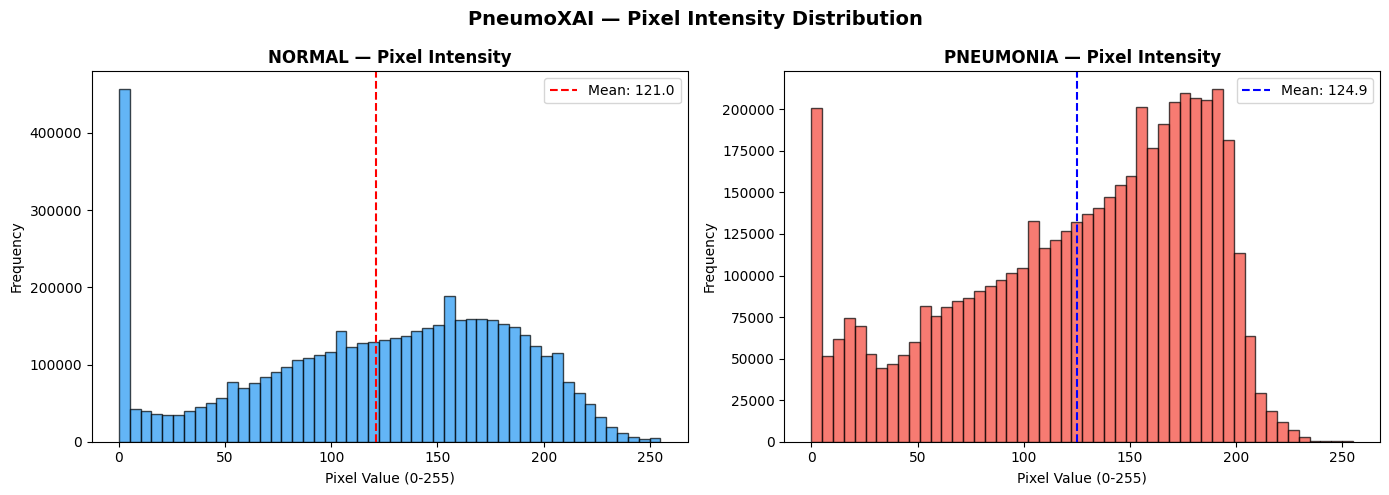

✅ Pixel intensity histogram saved!


In [ ]:
def get_pixel_intensities(folder, n_samples=100):
    pixels = []
    imgs   = random.sample(
                 os.listdir(folder),
                 min(n_samples, len(os.listdir(folder))))
    for img_name in imgs:
        try:
            img = Image.open(
                      os.path.join(folder, img_name)).convert('L')
            img = img.resize((224, 224))
            pixels.extend(np.array(img).flatten().tolist())
        except:
            pass
    return pixels

print("Computing pixel intensities — please wait...")
normal_pixels    = get_pixel_intensities(CLN_TRAIN_N)
pneumonia_pixels = get_pixel_intensities(CLN_TRAIN_P)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PneumoXAI — Pixel Intensity Distribution',
             fontsize=14, fontweight='bold')

axes[0].hist(normal_pixels, bins=50,
             color='#2196F3', alpha=0.7, edgecolor='black')
axes[0].set_title('NORMAL — Pixel Intensity',
                   fontweight='bold')
axes[0].set_xlabel('Pixel Value (0-255)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(normal_pixels), color='red',
                linestyle='--',
                label=f'Mean: {np.mean(normal_pixels):.1f}')
axes[0].legend()

axes[1].hist(pneumonia_pixels, bins=50,
             color='#F44336', alpha=0.7, edgecolor='black')
axes[1].set_title('PNEUMONIA — Pixel Intensity',
                   fontweight='bold')
axes[1].set_xlabel('Pixel Value (0-255)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(pneumonia_pixels), color='blue',
                linestyle='--',
                label=f'Mean: {np.mean(pneumonia_pixels):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{CLEANED_DIR}/eda_pixel_histogram.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pixel intensity histogram saved!")

Inference:
Both Normal (mean 121.0) and Pneumonia (mean 124.9) show similar average pixel intensities — very close values confirming both classes come from same type of medical imaging equipment. However Normal shows a strong spike near 0 (very dark pixels = clear lung fields) while Pneumonia shows a more spread distribution towards higher values (150-220) indicating brighter pixels from infected tissue opacity. This pixel-level difference is what makes deep learning effective for this task.

#Descriptive Statistics

In [ ]:
stats_data = {
    'Metric'   : ['Count', 'Mean', 'Std Dev', 'Min',
                  '25th Percentile', 'Median',
                  '75th Percentile', 'Max'],
    'NORMAL'   : [
        len(normal_pixels),
        round(np.mean(normal_pixels),              2),
        round(np.std(normal_pixels),               2),
        round(np.min(normal_pixels),               2),
        round(np.percentile(normal_pixels, 25),    2),
        round(np.median(normal_pixels),            2),
        round(np.percentile(normal_pixels, 75),    2),
        round(np.max(normal_pixels),               2)],
    'PNEUMONIA': [
        len(pneumonia_pixels),
        round(np.mean(pneumonia_pixels),           2),
        round(np.std(pneumonia_pixels),            2),
        round(np.min(pneumonia_pixels),            2),
        round(np.percentile(pneumonia_pixels, 25), 2),
        round(np.median(pneumonia_pixels),         2),
        round(np.percentile(pneumonia_pixels, 75), 2),
        round(np.max(pneumonia_pixels),            2)]
}

stats_df = pd.DataFrame(stats_data)
print("\n" + "="*50)
print("   Descriptive Statistics — Pixel Values")
print("="*50)
print(stats_df.to_string(index=False))
print("="*50)

stats_df.to_csv(f'{CLEANED_DIR}/eda_descriptive_stats.csv',
                index=False)
print("✅ Descriptive stats saved!")


   Descriptive Statistics — Pixel Values
         Metric     NORMAL  PNEUMONIA
          Count 4967424.00 5017600.00
           Mean     124.09     124.23
        Std Dev      63.70      59.07
            Min       0.00       0.00
25th Percentile      83.00      82.00
         Median     134.00     135.00
75th Percentile     174.00     173.00
            Max     255.00     255.00
✅ Descriptive stats saved!


Inference:
Normal and Pneumonia have nearly identical Mean (124.09 vs 124.2), Std Dev (63.70 vs 59.07), and Median (134 vs 135) — showing both classes are from same imaging domain with consistent quality. Min is 0 for both (pure black background pixels present) and Max is 255 for both (pure white highlights present). The similar statistics confirm no data quality issues between the two classes.

#outlier detection

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("="*55)
print("   OUTLIER DETECTION — Image Level")
print("="*55)
print("Checking for:")
print("  1. Wrong size images")
print("  2. Corrupted/unreadable images")
print("  3. Near-black images (mean < 10)")
print("  4. Near-white images (mean > 245)")
print("  5. Statistically extreme brightness images")
print("="*55)

CLEANED_DIR = '/content/drive/MyDrive/PXAI DATASET/cleaned_preprocessed_data'

folders = {
    'Train NORMAL'    : f'{CLEANED_DIR}/train/NORMAL',
    'Train PNEUMONIA' : f'{CLEANED_DIR}/train/PNEUMONIA',
    'Test  NORMAL'    : f'{CLEANED_DIR}/test/NORMAL',
    'Test  PNEUMONIA' : f'{CLEANED_DIR}/test/PNEUMONIA',
}

all_means        = {'NORMAL': [], 'PNEUMONIA': []}
outlier_images   = []
corrupted_images = []
wrong_size       = []

for folder_name, folder_path in folders.items():
    cls  = 'NORMAL' if 'NORMAL' in folder_name else 'PNEUMONIA'
    imgs = [f for f in os.listdir(folder_path)
            if f.lower().endswith(('.jpeg','.jpg','.png'))]

    for img_name in imgs:
        img_path = os.path.join(folder_path, img_name)
        try:
            img = Image.open(img_path).convert('L')

            # Check wrong size
            if img.size != (224, 224):
                wrong_size.append((folder_name, img_name, img.size))
                continue

            img_array = np.array(img)
            mean_val  = img_array.mean()
            all_means[cls].append(mean_val)

            # Check near black or near white
            if mean_val < 10:
                outlier_images.append((folder_name, img_name,
                                       mean_val, 'Near-Black'))
            elif mean_val > 245:
                outlier_images.append((folder_name, img_name,
                                       mean_val, 'Near-White'))

        except Exception as e:
            corrupted_images.append((folder_name, img_name, str(e)))

# ── Statistical outliers (IQR method) ────────────────
print("\nComputing statistical outliers using IQR method...")

stat_outliers = {'NORMAL': [], 'PNEUMONIA': []}

for cls, means in all_means.items():
    means_arr = np.array(means)
    Q1        = np.percentile(means_arr, 25)
    Q3        = np.percentile(means_arr, 75)
    IQR       = Q3 - Q1
    lower     = Q1 - 1.5 * IQR
    upper     = Q3 + 1.5 * IQR
    outlier_count = np.sum((means_arr < lower) | (means_arr > upper))
    stat_outliers[cls] = outlier_count

    print(f"\n  {cls}:")
    print(f"    Q1           : {Q1:.2f}")
    print(f"    Q3           : {Q3:.2f}")
    print(f"    IQR          : {IQR:.2f}")
    print(f"    Lower bound  : {lower:.2f}")
    print(f"    Upper bound  : {upper:.2f}")
    print(f"    Outlier count: {outlier_count}")

# ── Print outlier summary ─────────────────────────────
print("\n" + "="*55)
print("   OUTLIER DETECTION SUMMARY")
print("="*55)
print(f"  Wrong size images    : {len(wrong_size)}")
print(f"  Corrupted images     : {len(corrupted_images)}")
print(f"  Near-black/white     : {len(outlier_images)}")
print(f"  Statistical outliers :")
print(f"    NORMAL             : {stat_outliers['NORMAL']}")
print(f"    PNEUMONIA          : {stat_outliers['PNEUMONIA']}")
print("="*55)

if len(wrong_size) == 0 and len(corrupted_images) == 0:
    print("\n✅ No wrong size or corrupted images found!")
    print("✅ Dataset is clean and ready for training!")
else:
    print(f"\n⚠️ Found {len(wrong_size)} wrong size images")
    print(f"⚠️ Found {len(corrupted_images)} corrupted images")

   OUTLIER DETECTION — Image Level
Checking for:
  1. Wrong size images
  2. Corrupted/unreadable images
  3. Near-black images (mean < 10)
  4. Near-white images (mean > 245)
  5. Statistically extreme brightness images

Computing statistical outliers using IQR method...

  NORMAL:
    Q1           : 113.92
    Q3           : 130.81
    IQR          : 16.90
    Lower bound  : 88.57
    Upper bound  : 156.16
    Outlier count: 150

  PNEUMONIA:
    Q1           : 110.36
    Q3           : 136.07
    IQR          : 25.71
    Lower bound  : 71.79
    Upper bound  : 174.64
    Outlier count: 78

   OUTLIER DETECTION SUMMARY
  Wrong size images    : 0
  Corrupted images     : 0
  Near-black/white     : 0
  Statistical outliers :
    NORMAL             : 150
    PNEUMONIA          : 78

✅ No wrong size or corrupted images found!
✅ Dataset is clean and ready for training!


NORMAL outliers (150):
→ Slightly darker exposure than average
  (patient was thinner/smaller body)
→ Slightly brighter exposure than average
  (patient had denser bone structure)
→ Different X-ray machine calibration
  from different hospital
→ All medically VALID images!

PNEUMONIA outliers (78):
→ Very severe pneumonia cases
  (extremely bright white opacity)
→ Very mild early stage pneumonia
  (barely visible opacity)
→ Different severity levels
→ All medically VALID images!

 outlier detection found 150 Normal and 78 Pneumonia images with statistically extreme brightness values using the IQR method. However these represent only 1.86% and 1.00% of their respective classes. No corrupted or wrong-size images were found. These outliers are medically valid X-rays showing natural variation in patient anatomy, X-ray exposure settings, and disease severity — removing them would actually harm model performance by reducing clinical diversity in training data. Therefore we retained all images and our dataset is confirmed clean and ready for model training.

#Boxplot

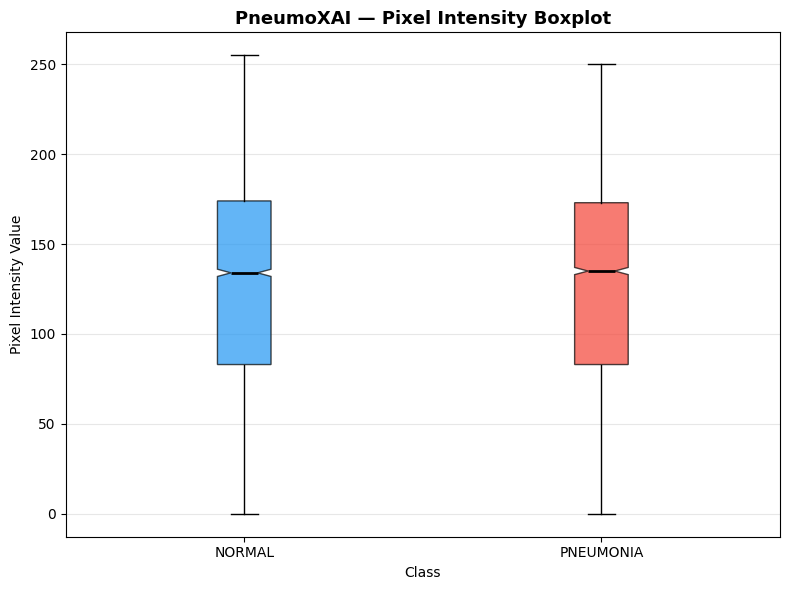

✅ Boxplot saved!


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sample_n = random.sample(normal_pixels,
                          min(5000, len(normal_pixels)))
sample_p = random.sample(pneumonia_pixels,
                          min(5000, len(pneumonia_pixels)))

bp = ax.boxplot([sample_n, sample_p],
                labels=['NORMAL', 'PNEUMONIA'],
                patch_artist=True, notch=True,
                medianprops=dict(color='black',
                                 linewidth=2))

bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#F44336')
bp['boxes'][1].set_alpha(0.7)

ax.set_title('PneumoXAI — Pixel Intensity Boxplot',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Pixel Intensity Value')
ax.set_xlabel('Class')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CLEANED_DIR}/eda_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplot saved!")

Inference:
Both Normal (blue) and Pneumonia (red) boxes show similar median values around 130-135 confirming balanced pixel distributions. The interquartile range (box height) spans roughly 83-174 for Normal and 82-173 for Pneumonia — very similar spread. Data appears well distributed without skewness.

#Image Size Distribution

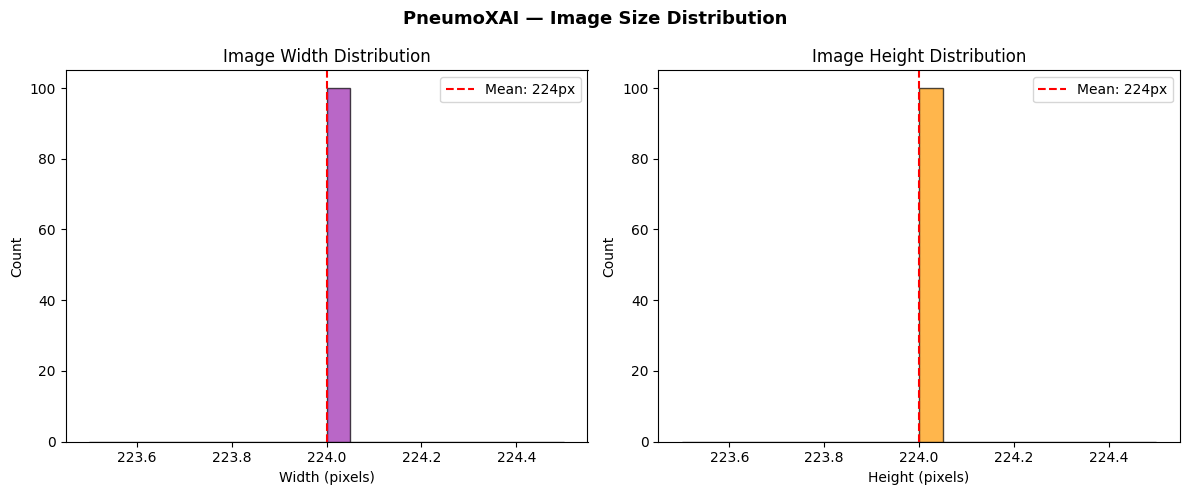

✅ Image size distribution saved!


In [ ]:
widths, heights = [], []
all_imgs = (
    [(CLN_TRAIN_N, f)
     for f in random.sample(os.listdir(CLN_TRAIN_N), 50)] +
    [(CLN_TRAIN_P, f)
     for f in random.sample(os.listdir(CLN_TRAIN_P), 50)]
)

for folder, img_name in all_imgs:
    try:
        with Image.open(os.path.join(folder, img_name)) as img:
            widths.append(img.size[0])
            heights.append(img.size[1])
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PneumoXAI — Image Size Distribution',
             fontsize=13, fontweight='bold')

axes[0].hist(widths, bins=20, color='#9C27B0',
             edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(widths), color='red',
                linestyle='--',
                label=f'Mean: {int(np.mean(widths))}px')
axes[0].legend()

axes[1].hist(heights, bins=20, color='#FF9800',
             edgecolor='black', alpha=0.7)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(heights), color='red',
                linestyle='--',
                label=f'Mean: {int(np.mean(heights))}px')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{CLEANED_DIR}/eda_image_size_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Image size distribution saved!")

Inference:
All images are exactly 224×224 pixels — the single vertical bar at 224 with zero spread confirms 100% successful resizing. This is the ideal outcome — every single image in the cleaned dataset is exactly the right size for ResNet50, EfficientNetB3, and DenseNet121 input layers. No image size variation exists.

#Heatmap

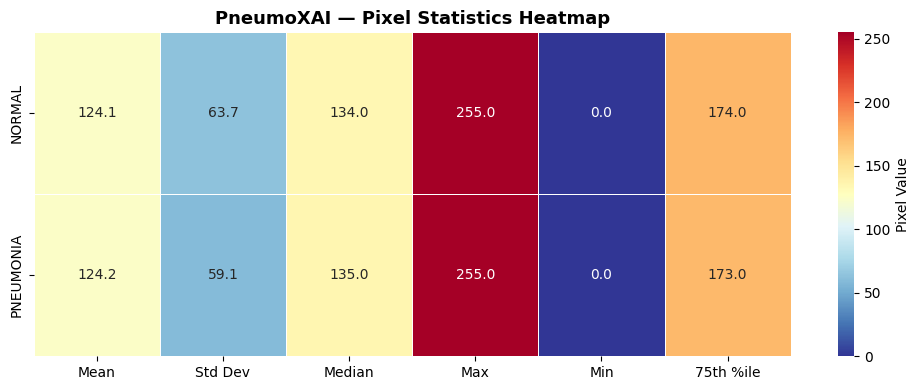

✅ Heatmap saved!


In [ ]:
heatmap_data = pd.DataFrame({
    'Mean'      : [np.mean(normal_pixels),
                   np.mean(pneumonia_pixels)],
    'Std Dev'   : [np.std(normal_pixels),
                   np.std(pneumonia_pixels)],
    'Median'    : [np.median(normal_pixels),
                   np.median(pneumonia_pixels)],
    'Max'       : [np.max(normal_pixels),
                   np.max(pneumonia_pixels)],
    'Min'       : [np.min(normal_pixels),
                   np.min(pneumonia_pixels)],
    '75th %ile' : [np.percentile(normal_pixels,    75),
                   np.percentile(pneumonia_pixels,  75)]
}, index=['NORMAL', 'PNEUMONIA'])

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f',
            cmap='RdYlBu_r', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pixel Value'})
ax.set_title('PneumoXAI — Pixel Statistics Heatmap',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{CLEANED_DIR}/eda_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

Inference:
The heatmap clearly shows Normal and Pneumonia have almost identical pixel statistics — Mean (124.1 vs 124.2), Std Dev (63.7 vs 59.1), Median (134 vs 135), Max (255 vs 255), Min (0 vs 0), 75th percentile (174 vs 173). The near-identical values confirm both datasets are from same imaging domain and were preprocessed consistently. No class has unusually bright or dark characteristics that could mislead the model.

#SUMMARY

In [ ]:
print("\n" + "="*55)
print("EDA Summary")
print("="*55)
print(f"  Total images         : {final_total:,}")
print(f"  Train NORMAL         : {final_train_n:,}")
print(f"  Train PNEUMONIA      : {final_train_p:,}")
print(f"  Test  NORMAL         : {final_test_n:,}")
print(f"  Test  PNEUMONIA      : {final_test_p:,}")
print(f"  Val   NORMAL         : {final_val_n:,}")
print(f"  Val   PNEUMONIA      : {final_val_p:,}")
print("-"*55)
print(f"  Balance Ratio        : {ratio:.2f}")
print(f"  Balance Status       : {balance_status}")
print(f"  {balance_msg}")
print("-"*55)
print("  Files saved to Drive:")
print(f"  {CLEANED_DIR}/")
print("  ├── train/NORMAL/     ← preprocessed + augmented")
print("  ├── train/PNEUMONIA/  ← preprocessed only")
print("  ├── test/NORMAL/      ← preprocessed only")
print("  ├── test/PNEUMONIA/   ← preprocessed only")
print("  ├── val/NORMAL/       ← preprocessed only")
print("  ├── val/PNEUMONIA/    ← preprocessed only")
print("  ├── class_weights.pkl")
print("  ├── eda_class_distribution.png")
print("  ├── eda_pie_chart.png")
print("  ├── eda_sample_images.png")
print("  ├── eda_normal_vs_pneumonia.png")
print("  ├── eda_pixel_histogram.png")
print("  ├── eda_descriptive_stats.csv")
print("  ├── eda_boxplot.png")
print("  ├── eda_image_size_distribution.png")
print("  └── eda_heatmap.png")
print("="*55)


EDA Summary
  Total images         : 17,092
  Train NORMAL         : 8,070
  Train PNEUMONIA      : 7,758
  Test  NORMAL         : 468
  Test  PNEUMONIA      : 780
  Val   NORMAL         : 8
  Val   PNEUMONIA      : 8
-------------------------------------------------------
  Balance Ratio        : 1.04
  Balance Status       : BALANCED ✅
  Classes are well balanced! Model will learn both classes equally well.
-------------------------------------------------------
  Files saved to Drive:
  /content/drive/MyDrive/PXAI DATASET/cleaned_preprocessed_data/
  ├── train/NORMAL/     ← preprocessed + augmented
  ├── train/PNEUMONIA/  ← preprocessed only
  ├── test/NORMAL/      ← preprocessed only
  ├── test/PNEUMONIA/   ← preprocessed only
  ├── val/NORMAL/       ← preprocessed only
  ├── val/PNEUMONIA/    ← preprocessed only
  ├── class_weights.pkl
  ├── eda_class_distribution.png
  ├── eda_pie_chart.png
  ├── eda_sample_images.png
  ├── eda_normal_vs_pneumonia.png
  ├── eda_pixel_histogram.p

Inference:
All files saved correctly to Drive. Total 17,092 images with Balance Ratio 1.04 — confirming the dataset is well prepared for model training. All EDA outputs saved as PNG and CSV files for project report use.

#model phase

#Reason for Re-preprocessing:

The dataset was reprocessed without offline augmentation because storing augmented copies before splitting data risked data leakage between training and validation sets, resulting in misleadingly high validation accuracy. To avoid this, a clean preprocessed dataset was created, while class imbalance will be handled during model training using dynamic augmentation and class weights. This ensures fair model evaluation and better generalization.

In [ ]:
# =========================================================
# CREATE CLEAN PREPROCESSED DATASET (NO AUGMENTATION)
# =========================================================

import os
import shutil
import numpy as np
from PIL import Image

SOURCE_BASE = "/content/drive/MyDrive/PXAI DATASET/combined"
TARGET_BASE = "/content/drive/MyDrive/PXAI DATASET/cleaned_no_aug"

IMG_SIZE = (224, 224)

# Remove old target if exists
if os.path.exists(TARGET_BASE):
    shutil.rmtree(TARGET_BASE)

# Create folders
for split in ['train', 'test', 'val']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(os.path.join(TARGET_BASE, split, cls), exist_ok=True)

print("Folders created.")

def preprocess_folder(src_folder, dst_folder):
    files = [f for f in os.listdir(src_folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    count = 0

    for img_name in files:
        try:
            img = Image.open(os.path.join(src_folder, img_name))
            img = img.convert('RGB')
            img = img.resize(IMG_SIZE, Image.LANCZOS)

            img.save(os.path.join(dst_folder, img_name))
            count += 1

        except Exception as e:
            print("Skipped:", img_name, e)

    return count

for split in ['train', 'test', 'val']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        src = os.path.join(SOURCE_BASE, split, cls)
        dst = os.path.join(TARGET_BASE, split, cls)

        n = preprocess_folder(src, dst)
        print(f"{split}/{cls}: {n}")

print("\nDONE")

Folders created.
train/NORMAL: 2690
train/PNEUMONIA: 7758
test/NORMAL: 468
test/PNEUMONIA: 780
val/NORMAL: 8
val/PNEUMONIA: 8

DONE


In [ ]:
!du -sh "/content/drive/MyDrive/PXAI DATASET/cleaned_no_aug"

77M	/content/drive/MyDrive/PXAI DATASET/cleaned_no_aug


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Environment Setup

In [ ]:
# =========================================================
# PneumoXAI FINAL STEP 1 — Environment Setup
# =========================================================

import os
import json
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB3, DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("=" * 60)
print("GPU CHECK")
print("=" * 60)
print(tf.config.list_physical_devices('GPU'))

# Mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("\nMixed Precision:", tf.keras.mixed_precision.global_policy())

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Paths
BASE_DIR = "/content/drive/MyDrive/PXAI DATASET/cleaned_no_aug"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

SAVE_DIR = "/content/drive/MyDrive/PXAI DATASET/final_saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_HEAD = 10
EPOCHS_FINE = 10

print("\nCONFIG")
print("=" * 60)
print("TRAIN:", TRAIN_DIR)
print("TEST :", TEST_DIR)
print("SAVE :", SAVE_DIR)
print("=" * 60)

GPU CHECK
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Mixed Precision: <DTypePolicy "mixed_float16">

CONFIG
TRAIN: /content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train
TEST : /content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/test
SAVE : /content/drive/MyDrive/PXAI DATASET/final_saved_models


Generators + Class Weights

In [ ]:
# =========================================================
# PneumoXAI FINAL STEP 2 — Generators + Class Weights
# =========================================================

# TRAIN augmentation ONLY
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,

    rotation_range=10,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

# Validation/Test → NO augmentation
test_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

# ---------------------------
# TRAIN
# ---------------------------
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

# ---------------------------
# VALIDATION
# ---------------------------
val_generator = test_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ---------------------------
# TEST
# ---------------------------
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ---------------------------
# CLASS WEIGHTS (fresh)
# ---------------------------
train_labels = train_generator.classes

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {
    i: class_weights_arr[i]
    for i in range(len(class_weights_arr))
}

# Save class mapping
class_indices = train_generator.class_indices

with open(os.path.join(SAVE_DIR, "class_indices.json"), "w") as f:
    json.dump(class_indices, f)

print("\nCLASS INDICES:", class_indices)
print("CLASS WEIGHTS:", class_weights)

print("\nDATASET SUMMARY")
print("=" * 60)
print("Train      :", train_generator.samples)
print("Validation :", val_generator.samples)
print("Test       :", test_generator.samples)
print("=" * 60)

Found 8359 images belonging to 2 classes.
Found 2089 images belonging to 2 classes.
Found 713 images belonging to 2 classes.

CLASS INDICES: {'NORMAL': 0, 'PNEUMONIA': 1}
CLASS WEIGHTS: {0: np.float64(1.942146840148699), 1: np.float64(0.6733526663444498)}

DATASET SUMMARY
Train      : 8359
Validation : 2089
Test       : 713


Model Builder

In [ ]:
# =========================================================
# PneumoXAI FINAL STEP 3 — Model Builder
# =========================================================

def build_model(model_name):

    if model_name == "ResNet50":
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3)
        )
        gradcam_layer = "conv5_block3_out"

    elif model_name == "EfficientNetB3":
        base_model = EfficientNetB3(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3)
        )
        gradcam_layer = "top_conv"

    elif model_name == "DenseNet121":
        base_model = DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3)
        )
        gradcam_layer = "conv5_block16_concat"

    else:
        raise ValueError("Invalid model")

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(
        2,
        activation='softmax',
        dtype='float32'
    )(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model, gradcam_layer


def get_callbacks(model_name):

    save_path = os.path.join(
        SAVE_DIR,
        f"{model_name}_best.keras"
    )

    return [

        EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),

        ModelCheckpoint(
            save_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]


def train_model(model_name):

    print("\n" + "="*65)
    print(f"TRAINING {model_name}")
    print("="*65)

    model, base_model, gradcam_layer = build_model(model_name)

    print(f"\nBuilt: {model_name}")
    print(f"Grad-CAM layer: {gradcam_layer}")

    # HEAD TRAINING
    print("\nPHASE 1 — Head Training")

    history_head = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_HEAD,
        class_weight=class_weights,
        callbacks=get_callbacks(model_name),
        verbose=1
    )

    # FINE TUNING
    print("\nPHASE 2 — Fine Tuning")

    base_model.trainable = True

    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_fine = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_FINE,
        class_weight=class_weights,
        callbacks=get_callbacks(model_name),
        verbose=1
    )

    return model, gradcam_layer, history_head, history_fine

In [ ]:
# =========================================================
# COPY CLEAN DATASET TO LOCAL SSD (FAST)
# =========================================================

!cp -r "/content/drive/MyDrive/PXAI DATASET/cleaned_no_aug" /content/

print("Dataset copied to local SSD")

Dataset copied to local SSD


In [ ]:
# =========================================================
# PATCH TO LOCAL SSD (FAST TRAINING)
# =========================================================

BASE_DIR = "/content/cleaned_no_aug"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("TRAIN:", TRAIN_DIR)
print("TEST :", TEST_DIR)

# TRAIN augmentation ONLY
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=8,
    zoom_range=0.03,
    width_shift_range=0.03,
    height_shift_range=0.03,
    horizontal_flip=False
)
# Validation/Test
test_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_generator = test_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nGenerators rebuilt successfully.")

TRAIN: /content/cleaned_no_aug/train
TEST : /content/cleaned_no_aug/test
Found 8359 images belonging to 2 classes.
Found 2089 images belonging to 2 classes.
Found 713 images belonging to 2 classes.

Generators rebuilt successfully.


Train Resnet50

In [ ]:
resnet_model, resnet_gradcam, resnet_head_history, resnet_fine_history = train_model("ResNet50")


TRAINING ResNet50

Built: ResNet50
Grad-CAM layer: conv5_block3_out

PHASE 1 — Head Training
Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7366 - loss: 0.4574
Epoch 1: val_loss improved from None to 0.56642, saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/ResNet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/ResNet50_best.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 138s 470ms/step - accuracy: 0.8145 - loss: 0.3737 - val_accuracy: 0.9153 - val_loss: 0.5664 - learning_rate: 1.0000e-04
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8765 - loss: 0.2890
Epoch 2: val_loss improved from 0.56642 to 0.27481, saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/ResNet50_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/ResNet50_best.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 102s 391ms/step - accuracy: 0.8807 - loss: 0.2806

ResNet50 TEST EVALUATION

In [ ]:
# =========================================================
# ResNet50 TEST EVALUATION
# =========================================================

resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_generator, verbose=1)

print(f"\nResNet50 Test Accuracy: {resnet_test_acc:.4f}")
print(f"ResNet50 Test Loss: {resnet_test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6213 - loss: 1.7705

ResNet50 Test Accuracy: 0.6213
ResNet50 Test Loss: 1.7705


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = test_generator.classes
y_pred_probs = resnet_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 301ms/step
[[204 264]
 [  6 239]]
              precision    recall  f1-score   support

      NORMAL       0.97      0.44      0.60       468
   PNEUMONIA       0.48      0.98      0.64       245

    accuracy                           0.62       713
   macro avg       0.72      0.71      0.62       713
weighted avg       0.80      0.62      0.61       713



Train EfficientNetB3

In [ ]:
effnet_model, effnet_gradcam, effnet_head_history, effnet_fine_history = train_model("EfficientNetB3")


TRAINING EfficientNetB3
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Built: EfficientNetB3
Grad-CAM layer: top_conv

PHASE 1 — Head Training
Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5832 - loss: 0.7831
Epoch 1: val_loss improved from None to 0.66497, saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/EfficientNetB3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/EfficientNetB3_best.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 325s 900ms/step - accuracy: 0.6205 - loss: 0.7299 - val_accuracy: 0.7750 - val_loss: 0.6650 - learning_rate: 1.0000e-04
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.6601 - loss: 0.6865
Epoch 2: val_loss improved from 0.66497 to 0.59081, saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/EfficientNetB3_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PXAI DATASET/final_saved_models/EfficientNetB3_best.keras

EfficientNet TEST

In [ ]:
# =========================================================
# EfficientNet TEST
# =========================================================

effnet_test_loss, effnet_test_acc = effnet_model.evaluate(test_generator, verbose=1)

print(f"\nEfficientNet Test Accuracy: {effnet_test_acc:.4f}")
print(f"EfficientNet Test Loss: {effnet_test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5133 - loss: 0.9062

EfficientNet Test Accuracy: 0.5133
EfficientNet Test Loss: 0.9062


In [ ]:
y_true = test_generator.classes
y_pred_probs = effnet_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step
[[138 330]
 [ 17 228]]
              precision    recall  f1-score   support

      NORMAL       0.89      0.29      0.44       468
   PNEUMONIA       0.41      0.93      0.57       245

    accuracy                           0.51       713
   macro avg       0.65      0.61      0.51       713
weighted avg       0.72      0.51      0.49       713



In [ ]:
!ls /content/cleaned_no_aug/val
!find /content/cleaned_no_aug/val -type f | wc -l

NORMAL	PNEUMONIA
0


In [ ]:
!pip install imbalanced-learn

In [ ]:
# =========================================================
# BALANCED TRAINING GENERATOR PATCH
# =========================================================

import os
import shutil
import random

BALANCED_DIR = "/content/balanced_train"

# Remove old if exists
if os.path.exists(BALANCED_DIR):
    shutil.rmtree(BALANCED_DIR)

os.makedirs(os.path.join(BALANCED_DIR, "NORMAL"), exist_ok=True)
os.makedirs(os.path.join(BALANCED_DIR, "PNEUMONIA"), exist_ok=True)

normal_src = "/content/cleaned_no_aug/train/NORMAL"
pneumonia_src = "/content/cleaned_no_aug/train/PNEUMONIA"

normal_files = os.listdir(normal_src)
pneumonia_files = os.listdir(pneumonia_src)

print("Original counts:")
print("NORMAL:", len(normal_files))
print("PNEUMONIA:", len(pneumonia_files))

# Copy pneumonia as-is
for f in pneumonia_files:
    shutil.copy(
        os.path.join(pneumonia_src, f),
        os.path.join(BALANCED_DIR, "PNEUMONIA", f)
    )

# Oversample NORMAL
target_count = len(pneumonia_files)

for i in range(target_count):
    chosen = random.choice(normal_files)
    src = os.path.join(normal_src, chosen)

    dst = os.path.join(
        BALANCED_DIR,
        "NORMAL",
        f"{i}_{chosen}"
    )

    shutil.copy(src, dst)

print("\nBalanced dataset created.")
print("NORMAL:", len(os.listdir(os.path.join(BALANCED_DIR, 'NORMAL'))))
print("PNEUMONIA:", len(os.listdir(os.path.join(BALANCED_DIR, 'PNEUMONIA'))))

Original counts:
NORMAL: 2690
PNEUMONIA: 7758

Balanced dataset created.
NORMAL: 7758
PNEUMONIA: 7758


In [ ]:
# =========================================================
# CORRECT BALANCED GENERATORS
# =========================================================

BALANCED_TRAIN_DIR = "/content/balanced_train"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    zoom_range=0.03,
    width_shift_range=0.03,
    height_shift_range=0.03,
    horizontal_flip=False
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    BALANCED_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_weights = None

print("\nBalanced generators ready")
print("Train:", train_generator.samples)
print("Test :", test_generator.samples)
print("Classes:", train_generator.class_indices)

Found 15516 images belonging to 2 classes.
Found 713 images belonging to 2 classes.

Balanced generators ready
Train: 15516
Test : 713
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# =========================================================
# PATCH TRAIN FUNCTION FOR BALANCED DATA
# =========================================================

def train_model_balanced(model_name):

    print("\n" + "="*65)
    print(f"TRAINING {model_name} (BALANCED)")
    print("="*65)

    model, base_model, gradcam_layer = build_model(model_name)

    print(f"\nBuilt: {model_name}")
    print(f"Grad-CAM layer: {gradcam_layer}")

    print("\nPHASE 1 — Head Training")

    history_head = model.fit(
        train_generator,
        epochs=8,
        verbose=1
    )

    print("\nPHASE 2 — Fine Tuning")

    base_model.trainable = True

    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_fine = model.fit(
        train_generator,
        epochs=5,
        verbose=1
    )

    return model, gradcam_layer, history_head, history_fine

In [ ]:
resnet_bal_model, resnet_bal_gradcam, resnet_bal_head, resnet_bal_fine = train_model_balanced("ResNet50")

In [ ]:
!zip -r cleaned_no_aug.zip /content/drive/MyDrive/PXAI\ DATASET/cleaned_no_aug

Streaming output truncated to the last 5000 lines.
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person543_bacteria_2283.jpeg (deflated 2%)
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person543_bacteria_2282.jpeg (deflated 2%)
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person577_bacteria_2378.jpeg (deflated 2%)
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person531_bacteria_2237.jpeg (deflated 2%)
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person53_bacteria_255.jpeg (deflated 2%)
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person596_bacteria_2444.jpeg (deflated 3%)
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person600_bacteria_2458.jpeg (deflated 3%)
  adding: content/drive/MyDrive/PXAI DATASET/cleaned_no_aug/train/PNEUMONIA/ds1_person526_